In [1]:
from functools import partial
import matplotlib.pyplot as plt
from superfv import HydroSolver, ics, TimeIntegrator, BC

In [2]:
N = 256
sim = HydroSolver(
    ic=partial(ics.sedov, gamma=1.4, h=1 / N),
    nx=N,
    ny=N,
    nz=N,
    bcx=(BC.REFLECTIVE, BC.FREE),
    bcy=(BC.REFLECTIVE, BC.FREE),
    bcz=(BC.REFLECTIVE, BC.FREE),
    p=1,
    use_MUSCL=True,
    cupy=True,
)

In [3]:
sim.take_n_steps(10, time_integrator=TimeIntegrator.MUSCL_HANCOCK, print_frequency=10)

SuperFV: step 10/10 | rho_min=1.16e-01 | E_cons=4.66e-09 | wall=1.17e+00s (done)


In [4]:
n_steps = sim.step_history[-1].step
n_xyz = sim.params.mesh.nx * sim.params.mesh.ny * sim.params.mesh.nz
t_wall = sum(x.timer["take_step"].cum_time for x in sim.step_history)
update_rate = n_steps * n_xyz / t_wall
print(f"{update_rate=:.2e} cell/s")

update_rate=1.47e+08 cell/s


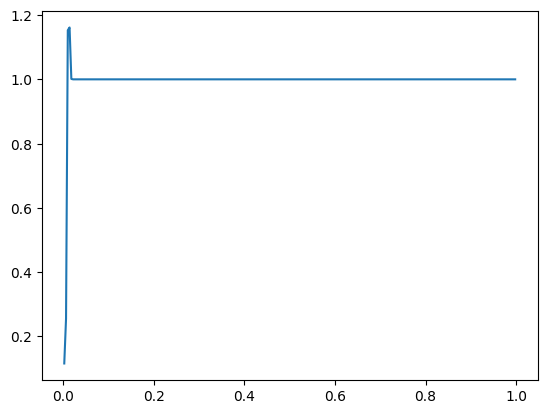

In [5]:
plt.plot(sim.mesh.x_centers, sim.snapshot_history[-1].u[sim.idx("rho"), :, 0, 0])

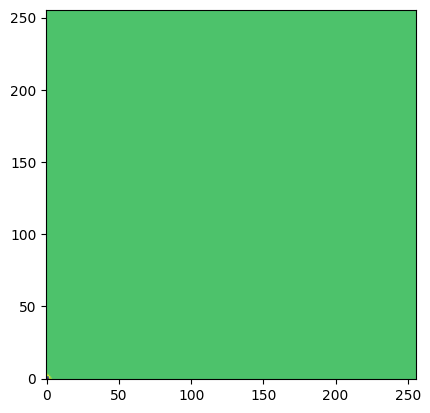

In [6]:
plt.imshow(sim.snapshot_history[-1].u[sim.idx("rho"), :, :, 0], origin="lower")